### Set of normalized machine numbers

Given $t$, $m$ and $M$, the set of (normalized!) machine numbers is defined as:

$$
    \mathcal{F}_{(t, m, M)} = \{0\} \cup \left\{ x \in \mathbb{R} : x = \pm \, 2^p \, \sum_{k = 1} ^ t \, d_k \, 2 ^{-k} \right\}
$$

Every binary number in it has exponent $p$ within $\left[ -m, M \right]$ and $d_k = 0; 1$ besides $d_1 = 1$ always. We can visualize this set to catch information

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def machine_numbers(t, m, M):

    n_mant = 2 ** (t - 1)  # Generate all positive mantissas (normalized, with implicit leading bit)
    mantissas = (n_mant + np.arange(n_mant)) / (2 ** t)   # values in [0.5, 1)
    exponents = 2.0 ** np.arange(-m, M + 1) # Generate all exponent factors

    positives = np.outer(exponents, mantissas).flatten() # All positive numbers = outer product of exponents and mantissas, flattened
    nums = np.concatenate(([0.0], positives, - positives)) # Combine zero, positives, and their negatives

    # Sort and plot
    x_vals = np.sort(nums)
    total = len(x_vals)

    plt.figure(figsize = (10, 2))
    plt.vlines(x_vals, ymin = 0, ymax = 1, colors = 'red', linewidth = 0.8, alpha = 0.7)
    plt.axhline(y = 0, color = 'black', linewidth = 0.8)
    plt.yticks([])
    plt.ylim(- 0.1, 1.3)
    plt.xlabel('Real values (x)')
    plt.title(rf'$\mathcal{{F}}_{{ (t = {t}, m = {m}, M = {M}) }}$  ({total} numbers)')
    plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
    plt.show()

    return x_vals

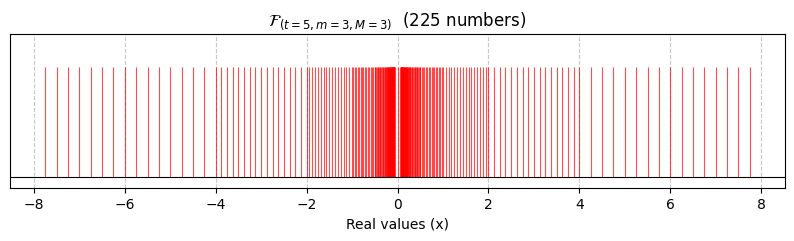

array([-7.75      , -7.5       , -7.25      , -7.        , -6.75      ,
       -6.5       , -6.25      , -6.        , -5.75      , -5.5       ,
       -5.25      , -5.        , -4.75      , -4.5       , -4.25      ,
       -4.        , -3.875     , -3.75      , -3.625     , -3.5       ,
       -3.375     , -3.25      , -3.125     , -3.        , -2.875     ,
       -2.75      , -2.625     , -2.5       , -2.375     , -2.25      ,
       -2.125     , -2.        , -1.9375    , -1.875     , -1.8125    ,
       -1.75      , -1.6875    , -1.625     , -1.5625    , -1.5       ,
       -1.4375    , -1.375     , -1.3125    , -1.25      , -1.1875    ,
       -1.125     , -1.0625    , -1.        , -0.96875   , -0.9375    ,
       -0.90625   , -0.875     , -0.84375   , -0.8125    , -0.78125   ,
       -0.75      , -0.71875   , -0.6875    , -0.65625   , -0.625     ,
       -0.59375   , -0.5625    , -0.53125   , -0.5       , -0.484375  ,
       -0.46875   , -0.453125  , -0.4375    , -0.421875  , -0.40

In [3]:
t, m, M = 5, 3, 3

nums = machine_numbers(t, m, M) # F(t = 5, m = M = 3)
nums

We can notice machine numbers aren't equally spaced. They are more clustered around zero. The absolute difference between 2 consecutive machine numbers is $2 ^ {p - t}$

In [4]:
np.unique(np.diff(nums[nums >= 0.0])) # Absolute difference between consecutive machine numbers (unique values)

array([0.00390625, 0.0078125 , 0.015625  , 0.03125   , 0.0625    ,
       0.125     , 0.25      ])

In [5]:
[2 ** (p - t) for p in range(- m, M + 1, 1)] # Theory formula

[0.00390625, 0.0078125, 0.015625, 0.03125, 0.0625, 0.125, 0.25]

Any real number $x$ between 2 consecutive machine numbers is approximated to the nearest machine number. The maximum absolute error committed is:

$$
    E_x = 2^{p - t - 1}
$$

The relative error is:

$$
    \varepsilon_x = \frac{E_x}{|x|}
$$

Because $|x| = 2^{p} \, M$, where M is the Mantissa, and $\frac{1}{2} \leq M \leq 1$, the upper bound of the relative error is:

$$
    \varepsilon_x \leq \frac{2 ^ {p - t - 1}}{2 ^ {p - 1}} = 2 ^ {- t} = \frac{1}{2} \, \varepsilon_{mach}
$$

Where $\varepsilon_{mach}$ is the machine precision constant, equal to:

$$
    \varepsilon_{mach} = 2^{1 - t}
$$

$\varepsilon_{mach}$ is the absolute difference between $1$ and the nearest positive machine number of the set

In [6]:
# Computing machine precision
np.where(nums == 1.0)[0] # index of nums == 1.0

array([177])

In [7]:
nums[178] - 1.0 # Machine precision for our set

np.float64(0.0625)

In [8]:
2 ** (1 - t) # Theory formula

0.0625

In [9]:
2 ** (- t) * 100.0 # Maximum relative error [%] for our set

3.125

Standard IEEE 754 sets $t = 24$ for floats (single precision) and $t = 53$ for doubles (double precision)

In [10]:
# Machine precision for floats, Standard IEEE 754
eps_mach = np.float32(1.0)
i = 0 # Number of iterations
while (np.float32(1.0) + eps_mach / np.float32(2.0)) != np.float32(1.0):
    eps_mach /= np.float32(2.0)
    i += 1

eps_mach, i

(np.float32(1.1920929e-07), 23)

In [11]:
2 ** (1 - 24) # Definition of machine precision for floats

1.1920928955078125e-07

In [12]:
# Machine precision for doubles, Standard IEEE 754
eps_mach = 1.0
i = 0
while (1.0 + eps_mach / 2.0) != 1.0:
    eps_mach /= 2.0
    i += 1

eps_mach, i

(2.220446049250313e-16, 52)

In [13]:
2 ** (1 - 53) # Definition of machine precision for doubles

2.220446049250313e-16